<a href="https://colab.research.google.com/github/huyle2411-hub/credit-risk-scorecard/blob/main/notebooks/03_scorecard_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Scorecard — Notebook 03: Scorecard Evaluation

**Goal of this notebook:** train the logistic scorecard on WOE variables, evaluate it (AUC, KS, Gini, calibration), convert scores to points, and check PSI.

In [ ]:
!pip install optbinning -q
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from optbinning import BinningProcess
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
import statsmodels.api as sm
pd.set_option('display.max_columns', None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 18.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatible.
grain 0.2.18 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
tensorflow 2.20.0 requires protobuf>=5.28.0, but you have protobuf 5.26.1 which is incompatible.


##1. Nạp và chạy lại pipeline làm sạch của Notebook 02
Repeat cleaning, WOE, and feature selection at IV ≥ 0.05.

In [10]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('cs-training.csv', index_col=0)
target = 'SeriousDlqin2yrs'
late = ['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTimes90DaysLate','NumberOfTime60-89DaysPastDueNotWorse']

# --- lap lai cleaning tu NB02 (de notebook nay tu chay duoc) ---
d = df.copy()
d['severe_delinq_flag'] = (d[late] >= 90).any(axis=1).astype(int)
d[late] = d[late].mask(d[late] >= 90)
d['age'] = d['age'].replace(0, np.nan)
for c in ['RevolvingUtilizationOfUnsecuredLines','DebtRatio']:
    d[c] = d[c].clip(upper=d[c].quantile(0.99))
d['NumberOfDependents'] = d['NumberOfDependents'].fillna(0)

# --- WOE transform + chon bien IV>=0.05 ---
y = d[target].values
X = d.drop(columns=[target])
bp = BinningProcess(variable_names=list(X.columns)); bp.fit(X.values, y)
Xw = pd.DataFrame(bp.transform(X.values), columns=X.columns, index=X.index)
iv = bp.summary().set_index('name')['iv']
keep = [c for c in X.columns if iv[c] >= 0.05]
Xw = Xw[keep]
print('Bien dung cho model (%d):' % len(keep), keep)

Saving cs-training.csv to cs-training (1).csv
Bien dung cho model (8): ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines']


##2. Train/test split with stratification

The data is split into train and test to measure how well the model generalises to unseen data. `stratify` keeps the default rate of about 6.7 percent in both parts, which matters because the data is imbalanced. A purely random split could shift that rate enough to distort the evaluation.




In [11]:
Xtr, Xte, ytr, yte = train_test_split(Xw, y, test_size=0.3, stratify=y, random_state=42)
print('train:', Xtr.shape, ' test:', Xte.shape)

train: (105000, 8)  test: (45000, 8)


##3. Logistic Regression

Logistic regression is the main model because it is the common standard for bank scorecards: transparent, with coefficients that can be explained, easy to audit, and easy to turn into credit policy. The goal is not only the highest accuracy but also explainability and risk governance.



In [12]:
logit = sm.Logit(ytr, sm.add_constant(Xtr)).fit(disp=0)
p_tr = logit.predict(sm.add_constant(Xtr))
p_te = logit.predict(sm.add_constant(Xte))
print(logit.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               105000
Model:                          Logit   Df Residuals:                   104991
Method:                           MLE   Df Model:                            8
Date:                Sun, 05 Jul 2026   Pseudo R-squ.:                  0.2411
Time:                        18:35:15   Log-Likelihood:                -19552.
converged:                       True   LL-Null:                       -25765.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -2.6128      0.015   -171.976      0.000      -2.643      -2.583
RevolvingUtilizationOfUnsecuredLines    -0.6418      

##4. AUC, KS, Gini

AUC measures how well the model ranks higher-risk customers above lower-risk ones, so a higher AUC means better separation. KS is the largest gap between the cumulative distributions of the good and bad groups, showing how well the two are separated. Gini is another form of AUC, computed as Gini = 2 × AUC − 1, and higher is stronger.

TEST  AUC = 0.8511 | Gini = 0.7022 | KS = 0.5506
TRAIN AUC = 0.8507  (so sanh de kiem overfit)


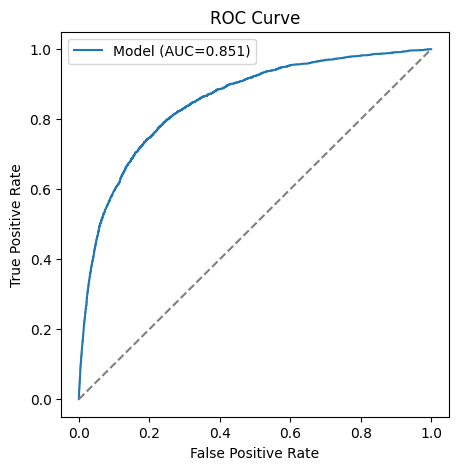

In [13]:
def ks_stat(y_true, prob):
    fpr, tpr, _ = roc_curve(y_true, prob)
    return np.max(tpr - fpr)

auc = roc_auc_score(yte, p_te)
print('TEST  AUC = %.4f | Gini = %.4f | KS = %.4f' % (auc, 2*auc-1, ks_stat(yte, p_te)))
print('TRAIN AUC = %.4f  (so sanh de kiem overfit)' % roc_auc_score(ytr, p_tr))

fpr, tpr, _ = roc_curve(yte, p_te)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label='Model (AUC=%.3f)' % auc)
plt.plot([0,1],[0,1],'--',color='grey')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend(); plt.show()

##5. Calibration

Calibration checks whether the predicted default probabilities match the actual default rates. This matters for a scorecard because a bank needs the PD itself to be correct, not just the ranking of customers.



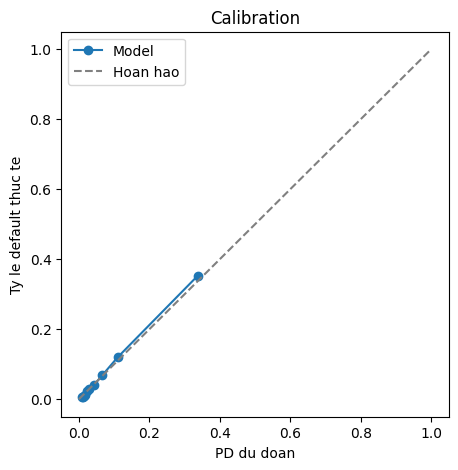

In [14]:
frac_pos, mean_pred = calibration_curve(yte, p_te, n_bins=10, strategy='quantile')
plt.figure(figsize=(5,5))
plt.plot(mean_pred, frac_pos, 'o-', label='Model')
plt.plot([0,1],[0,1],'--',color='grey', label='Hoan hao')
plt.xlabel('PD du doan'); plt.ylabel('Ty le default thuc te')
plt.title('Calibration'); plt.legend(); plt.show()

##6. Converting PD to points (PDO)

The default probability is turned into a credit score using PDO = 20, meaning every 20 points doubles the good-to-bad odds. The scale is anchored at 600 points at odds of 50 to 1, so a higher score means lower risk.



Diem: min 433 | mean 583 | max 634


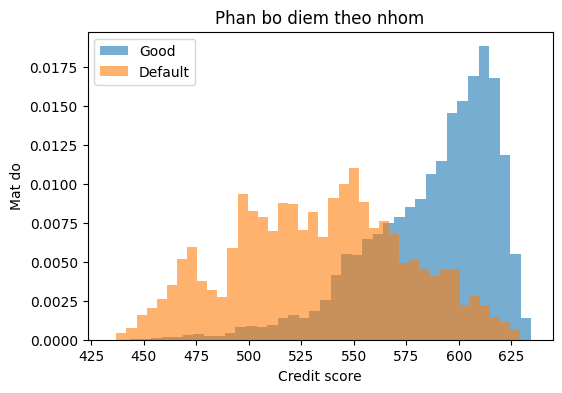

In [15]:
factor = 20 / np.log(2)
offset = 600 - factor * np.log(50)

def to_score(p):
    odds = (1 - p) / np.clip(p, 1e-9, 1)
    return offset + factor * np.log(odds)

score_te = to_score(p_te)
print('Diem: min %.0f | mean %.0f | max %.0f' % (score_te.min(), score_te.mean(), score_te.max()))

plt.figure(figsize=(6,4))
plt.hist(score_te[yte==0], bins=40, alpha=0.6, label='Good', density=True)
plt.hist(score_te[yte==1], bins=40, alpha=0.6, label='Default', density=True)
plt.xlabel('Credit score'); plt.ylabel('Mat do'); plt.title('Phan bo diem theo nhom')
plt.legend(); plt.show()

##7. PSI

PSI (Population Stability Index) measures how much the score distribution shifts between two datasets, and a value below 0.1 is usually considered stable. One caveat: here train and test are random splits of the same dataset, so a PSI near 0 is expected. This does not prove the model is stable over real time. That would require comparing against data from later periods.



In [16]:
def psi(expected, actual, bins=10):
    q = np.quantile(expected, np.linspace(0,1,bins+1)); q[0]=-np.inf; q[-1]=np.inf
    e = np.clip(np.histogram(expected, q)[0]/len(expected), 1e-6, None)
    a = np.clip(np.histogram(actual, q)[0]/len(actual), 1e-6, None)
    return np.sum((a - e) * np.log(a / e))

print('PSI (train vs test): %.4f' % psi(to_score(p_tr), score_te))

PSI (train vs test): 0.0004


**→** PSI comes out at 0.0004. Next, Notebook 04 compares the scorecard against a boosting challenger and rewrites the scoring logic in SQL (DuckDB).

